<a href="https://colab.research.google.com/github/mbenedicto99/artificial_intelligence/blob/master/BENE_PECE_2026_Rede_Recorrente_Cl%C3%A1ssica_ipynb_json.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Rede Recorrente Clássica para Análise de Sentimentos

Nesta demonstração, vamos usar o banco de resenhas do IMDB, que classifica os textos em positivo (0) ou negativo (1).

Adaptado de Chollet (2018).

**Importação dos dados e criação dos datasets**

In [1]:
from keras.layers import SimpleRNN, Embedding, Dense
from keras.models import Sequential
from keras.utils import pad_sequences

import numpy as np
import matplotlib.pyplot as plt


In [2]:
from keras.datasets import imdb
from keras.preprocessing import sequence
max_features = 10000
maxlen = 500

In [3]:
(input_train, y_train), (input_test, y_test) = imdb.load_data(num_words=max_features)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [4]:
input_train[:2]

array([list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]),
       list([1, 194, 1153, 194, 8255, 78, 228,

In [5]:
type(input_train[0])

list

In [6]:
print(len(input_train), len(input_test))  # Só para conferir: cada conjunto terá 25.000 resenhas

25000 25000


In [7]:
# Os textos das resenhas têm tamanhos diferentes
tamanhos = [len(i) for i in input_train]

# Conferindo...
print(np.max(tamanhos), np.mean(tamanhos))
tamanhos[:5]

2494 238.71364


[218, 189, 141, 550, 147]

In [8]:
# Qual o tamanho máximo a considerar para as resenhas?
print(maxlen)

# Preencher os vetores menores até o tamanho máximo, para entregar sempre as mesmas dimensões.
input_train = pad_sequences(input_train, maxlen=maxlen)

# Conferindo...
print(input_train.shape)

# Mesmo preenchimento com o dataset de teste
input_test = pad_sequences(input_test, maxlen=maxlen)

500
(25000, 500)


In [9]:
# Cada item dos datasets é um vetor esparso de índices de palavras,
# com o preenchedor no início. Por ex.:
input_train[5]

array([   0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

In [10]:
type(y_train[0])

numpy.int64

In [11]:
# A camada Embedding transforma vetores esparsos (de índices de palavras)
# em vetores densos de dimensões pré-definidas (32, no caso).
# Só pode ser usada como camada de entrada.

model = Sequential()
model.add(Embedding(max_features, 32))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

In [12]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(input_train, y_train,
                     epochs=10,
                     batch_size=128,
                     validation_split=0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 47s 271ms/step - acc: 0.5831 - loss: 0.6666 - val_acc: 0.7570 - val_loss: 0.5352
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 22s 143ms/step - acc: 0.7889 - loss: 0.4611 - val_acc: 0.7666 - val_loss: 0.4816
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - acc: 0.8510 - loss: 0.3518 - val_acc: 0.8000 - val_loss: 0.4335
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - acc: 0.8866 - loss: 0.2778 - val_acc: 0.8432 - val_loss: 0.3889
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 12s 76ms/step - acc: 0.9187 - loss: 0.2131 - val_acc: 0.7930 - val_loss: 0.4902
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 26s 164ms/step - acc: 0.9489 - loss: 0.1422 - val_acc: 0.8358 - val_loss: 0.4643
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 155ms/step - acc: 0.9739 - loss: 0.0849 - val_acc: 0.7406 - val_loss: 0.6722
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 27s 173ms/step - acc: 0.9842 - loss: 0.0553 - val_acc: 0.7752 - val_loss: 0.6755
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━

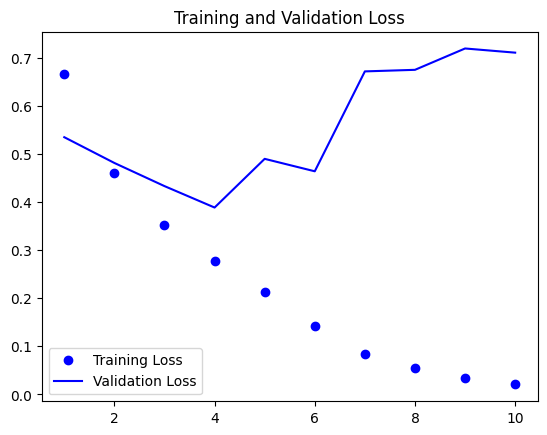

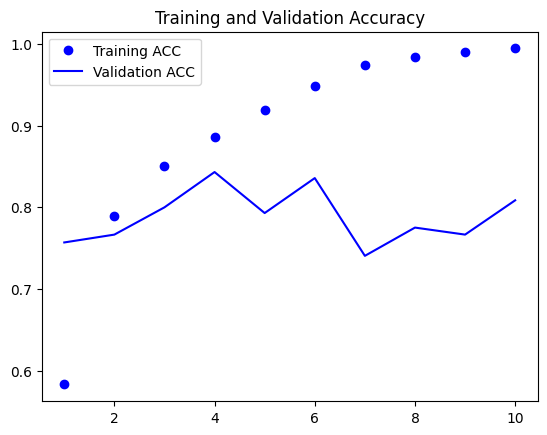

In [13]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.figure()

plt.plot(epochs, acc, 'bo', label='Training ACC')
plt.plot(epochs, val_acc, 'b', label='Validation ACC')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

**Tentando melhorar...**

In [14]:
# Desta vez, o parâmetro return_sequences (com True) devolverá toda
# a sequência temporal, não só o último estado (que é o default).

model = Sequential()
model.add(Embedding(max_features, 32))
model.add(SimpleRNN(32, return_sequences=True))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

In [15]:
model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history = model.fit(input_train, y_train,
                     epochs=10,
                     batch_size=128,
                     validation_split=0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 193ms/step - acc: 0.5703 - loss: 0.6679 - val_acc: 0.7140 - val_loss: 0.5653
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 30s 193ms/step - acc: 0.7937 - loss: 0.4469 - val_acc: 0.6330 - val_loss: 0.8088
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 89ms/step - acc: 0.8774 - loss: 0.3016 - val_acc: 0.8008 - val_loss: 0.4551
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - acc: 0.9320 - loss: 0.1813 - val_acc: 0.8264 - val_loss: 0.4823
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 90ms/step - acc: 0.9668 - loss: 0.0977 - val_acc: 0.8070 - val_loss: 0.5739
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 14s 87ms/step - acc: 0.9855 - loss: 0.0435 - val_acc: 0.7844 - val_loss: 0.7776
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 85ms/step - acc: 0.9916 - loss: 0.0250 - val_acc: 0.7900 - val_loss: 0.8224
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 82ms/step - acc: 0.9969 - loss: 0.0109 - val_acc: 0.7750 - val_loss: 1.0106
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━

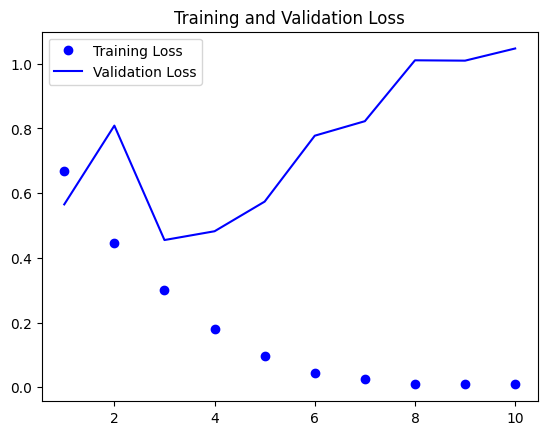

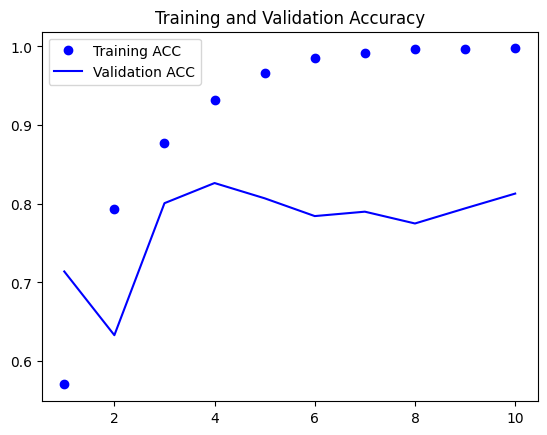

In [16]:
acc = history.history['acc']
val_acc = history.history['val_acc']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.figure()

plt.plot(epochs, acc, 'bo', label='Training ACC')
plt.plot(epochs, val_acc, 'b', label='Validation ACC')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

## Sugestões para Melhorar o Treinamento

In [17]:
from keras.layers import LSTM, Dropout

# Modelo com camadas LSTM e Dropout para evitar overfitting
model_lstm = Sequential()
model_lstm.add(Embedding(max_features, 32))
model_lstm.add(LSTM(32, return_sequences=True)) # Use LSTM e return_sequences para a primeira camada
model_lstm.add(Dropout(0.5)) # Adicione Dropout após a primeira camada LSTM
model_lstm.add(LSTM(32)) # Segunda camada LSTM
model_lstm.add(Dropout(0.5)) # Adicione Dropout após a segunda camada LSTM
model_lstm.add(Dense(1, activation='sigmoid'))

model_lstm.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
model_lstm.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['acc'])

history_lstm = model_lstm.fit(input_train, y_train,
                     epochs=10,
                     batch_size=128,
                     validation_split=0.2)

Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 38ms/step - acc: 0.6478 - loss: 0.6154 - val_acc: 0.6784 - val_loss: 0.5849
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.8174 - loss: 0.4274 - val_acc: 0.8322 - val_loss: 0.3848
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - acc: 0.8619 - loss: 0.3469 - val_acc: 0.8646 - val_loss: 0.3331
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.8778 - loss: 0.3073 - val_acc: 0.8682 - val_loss: 0.3215
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.8964 - loss: 0.2739 - val_acc: 0.8816 - val_loss: 0.2905
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - acc: 0.9017 - loss: 0.2585 - val_acc: 0.8738 - val_loss: 0.3382
Epoch 7/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 35ms/step - acc: 0.9075 - loss: 0.2466 - val_acc: 0.8756 - val_loss: 0.3001
Epoch 8/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - acc: 0.9150 - loss: 0.2205 - val_acc: 0.8832 - val_loss: 0.3046
Epoch 9/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 36m

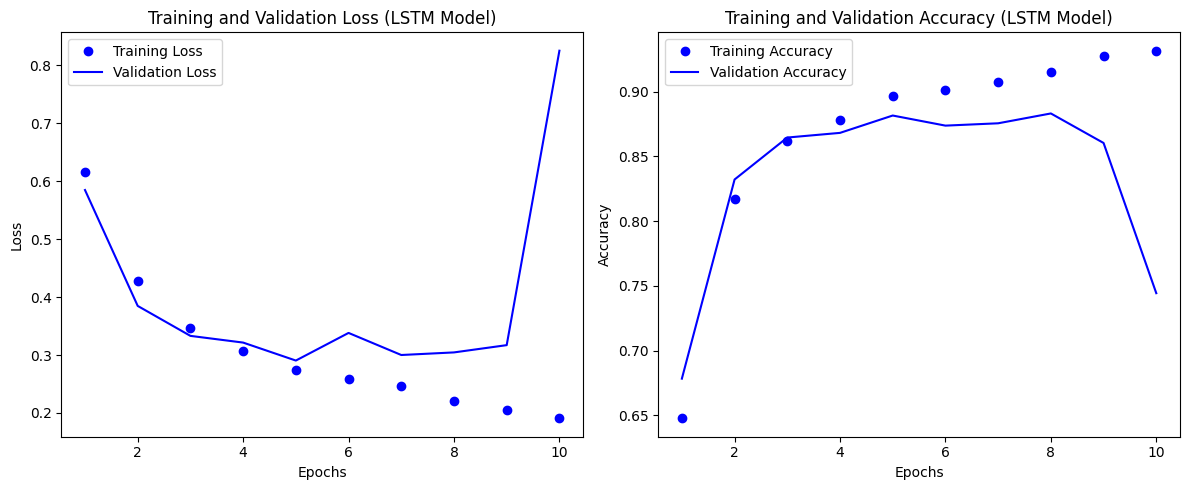

In [19]:
acc_lstm = history_lstm.history['acc']
val_acc_lstm = history_lstm.history['val_acc']
loss_lstm = history_lstm.history['loss']
val_loss_lstm = history_lstm.history['val_loss']
epochs_lstm = range(1, len(acc_lstm) + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_lstm, loss_lstm, 'bo', label='Training Loss')
plt.plot(epochs_lstm, val_loss_lstm, 'b', label='Validation Loss')
plt.title('Training and Validation Loss (LSTM Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_lstm, acc_lstm, 'bo', label='Training Accuracy')
plt.plot(epochs_lstm, val_acc_lstm, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy (LSTM Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()